In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [30]:
df = pd.read_csv('data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.shape

(1460, 81)

**Uniforming the column names**

In [38]:
df = df.rename(columns={i:i.lower() for i in df.columns})

**Feature Engineering**

In [39]:
df['age'] = df['yrsold'] - df['yearbuilt']  #making a new column called age which denotes the age of the house, subtracting yearsold and yearbuilt
df['remode_age'] = df['yrsold'] - df['yearremodadd'] #counting the number of years since the year when the house was renovated till the year it was sold.
df = df.drop(columns = ['yrsold','yearbuilt','yearremodadd','id'])

In [40]:
df.columns


Index(['mssubclass', 'mszoning', 'lotfrontage', 'lotarea', 'street', 'alley',
       'lotshape', 'landcontour', 'utilities', 'lotconfig', 'landslope',
       'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle',
       'overallqual', 'overallcond', 'roofstyle', 'roofmatl', 'exterior1st',
       'exterior2nd', 'masvnrtype', 'masvnrarea', 'exterqual', 'extercond',
       'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure', 'bsmtfintype1',
       'bsmtfinsf1', 'bsmtfintype2', 'bsmtfinsf2', 'bsmtunfsf', 'totalbsmtsf',
       'heating', 'heatingqc', 'centralair', 'electrical', '1stflrsf',
       '2ndflrsf', 'lowqualfinsf', 'grlivarea', 'bsmtfullbath', 'bsmthalfbath',
       'fullbath', 'halfbath', 'bedroomabvgr', 'kitchenabvgr', 'kitchenqual',
       'totrmsabvgrd', 'functional', 'fireplaces', 'fireplacequ', 'garagetype',
       'garageyrblt', 'garagefinish', 'garagecars', 'garagearea', 'garagequal',
       'garagecond', 'paveddrive', 'wooddecksf', 'openporchsf',
       'en

**Checking the null values**

In [41]:
num_null_features = df.isnull().any().sum()
print(f'The total number of features having null values are: {num_null_features}')

The total number of features having null values are: 19


**Checking the features having null values**

In [42]:
null_features = df.isnull().sum()[df.isnull().sum()>0]
print(f'The features having the null values are: \n{null_features}')

The features having the null values are: 
lotfrontage      259
alley           1369
masvnrtype       872
masvnrarea         8
bsmtqual          37
bsmtcond          37
bsmtexposure      38
bsmtfintype1      37
bsmtfintype2      38
electrical         1
fireplacequ      690
garagetype        81
garageyrblt       81
garagefinish      81
garagequal        81
garagecond        81
poolqc          1453
fence           1179
miscfeature     1406
dtype: int64


**here none_features means the features where na means the house donot have this feature, it doesnot mean the value is actually null or missing**
**So we are filling the na values of these features with None**

In [45]:
none_features = ['poolqc','miscfeature','alley','fence','fireplacequ',
                 'garagetype','garagefinish','garagequal','garagecond',
                 'bsmtqual','bsmtcond','bsmtexposure','bsmtfintype1','bsmtfintype2',
                 'masvnrtype']
for col in none_features:
    df[col] = df[col].fillna('None')

**same here for the zero_features, where na means the house donot have this feature**

In [47]:
zero_features = ['garageyrblt','garagearea','garagecars',
                 'bsmtfinsf1','bsmtfinsf2','bsmtunfsf','totalbsmtsf',
                 'bsmtfullbath','bsmthalfbath','masvnrarea']
for col in zero_features:
    df[col] = df[col].fillna(0)

KeyError: 'GarageYrBlt'

**Checking the features having duplicate values**

In [20]:
df.duplicated().sum()

np.int64(0)

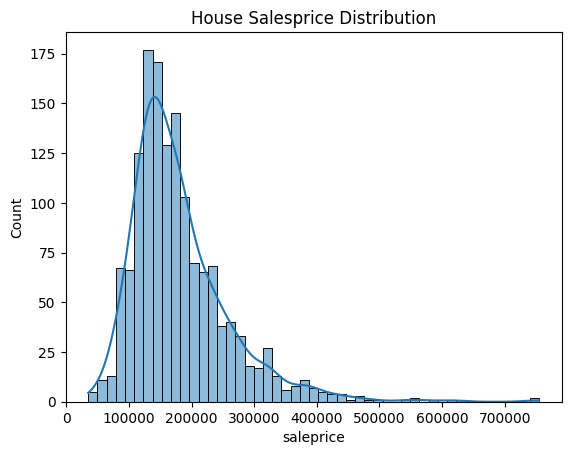

In [10]:
sns.histplot(df['saleprice'],kde=True)
plt.title('House Salesprice Distribution')
plt.show()


**We can observe from the plot above that the majority of house salesprice lie between the range of 150000 and 250000**

In [11]:
df['mssubclass'] = df['mssubclass'].astype(str)

In [12]:
df['mszoning'].value_counts()

mszoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

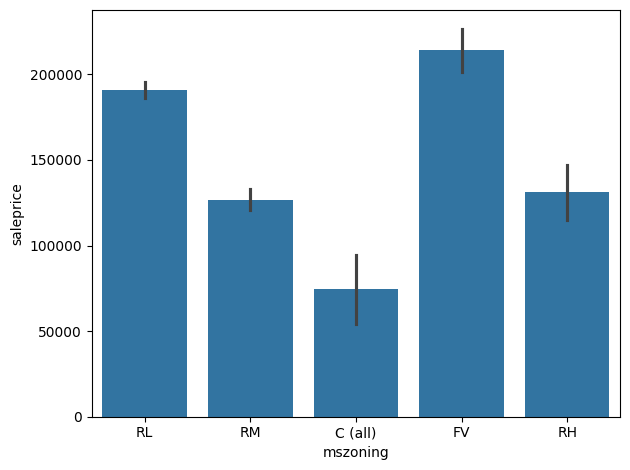

In [13]:
sns.barplot(x='mszoning',y='saleprice',data=df)
plt.tight_layout()
plt.show()

**“The bar plot indicates that zoning classification has a significant impact on sale price. Properties in premium residential zones such as FV exhibit the highest average prices, followed by RL (suburban residential areas). Meanwhile, properties in commercial zones (C) show comparatively lower average prices, possibly due to differences in property type and limited representation in the dataset.”**

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mssubclass     1460 non-null   str    
 1   mszoning       1460 non-null   str    
 2   lotfrontage    1201 non-null   float64
 3   lotarea        1460 non-null   int64  
 4   street         1460 non-null   str    
 5   alley          91 non-null     str    
 6   lotshape       1460 non-null   str    
 7   landcontour    1460 non-null   str    
 8   utilities      1460 non-null   str    
 9   lotconfig      1460 non-null   str    
 10  landslope      1460 non-null   str    
 11  neighborhood   1460 non-null   str    
 12  condition1     1460 non-null   str    
 13  condition2     1460 non-null   str    
 14  bldgtype       1460 non-null   str    
 15  housestyle     1460 non-null   str    
 16  overallqual    1460 non-null   int64  
 17  overallcond    1460 non-null   int64  
 18  roofstyle      1460

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [15]:
numerical_features = df.select_dtypes(include = np.number).columns.tolist()  #grabbing all the features of type number 'int or float'
categorical_features = df.select_dtypes(exclude = np.number).columns.tolist()  #grabbing the features which are not of type number
print(f'The categorical features are: {categorical_features} \n')
print(f'The numerical features are: {numerical_features}')
print(f'The number of numerical features is: {len(numerical_features)}')
print(f'The number of categorical features is: {len(categorical_features)}')

The categorical features are: ['mssubclass', 'mszoning', 'street', 'alley', 'lotshape', 'landcontour', 'utilities', 'lotconfig', 'landslope', 'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle', 'roofstyle', 'roofmatl', 'exterior1st', 'exterior2nd', 'masvnrtype', 'exterqual', 'extercond', 'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure', 'bsmtfintype1', 'bsmtfintype2', 'heating', 'heatingqc', 'centralair', 'electrical', 'kitchenqual', 'functional', 'fireplacequ', 'garagetype', 'garagefinish', 'garagequal', 'garagecond', 'paveddrive', 'poolqc', 'fence', 'miscfeature', 'saletype', 'salecondition'] 

The numerical features are: ['lotfrontage', 'lotarea', 'overallqual', 'overallcond', 'masvnrarea', 'bsmtfinsf1', 'bsmtfinsf2', 'bsmtunfsf', 'totalbsmtsf', '1stflrsf', '2ndflrsf', 'lowqualfinsf', 'grlivarea', 'bsmtfullbath', 'bsmthalfbath', 'fullbath', 'halfbath', 'bedroomabvgr', 'kitchenabvgr', 'totrmsabvgrd', 'fireplaces', 'garageyrblt', 'garagecars', 'garagearea', 'wood

**here we have differentiated the categorical datas into datas that need one hot encoding or binary encoding or ordinal encoding based on the values of the data**

In [22]:
one_hot_encode_nominal_cat= ['mssubclass','mszoning','alley','landcontour','lotconfig','neighborhood','condition1','condition2','bldgtype','housestyle','roofstyle','roofmatl','exterior1st','exterior1st','masvnrtype','foundation','heating','garagetype','miscfeature','saletype','salecondition']
binary_encode_nominal_cat = ['street','centralair']
ordinal_cat = ['lotshape','utilities','landslope','exterqual','extercond','bsmtqual','bsmtcond','bsmtexposure','bsmtfintype1','bsmtfintype2','heatingqc','kitchenqual','fireplacequ','functional','garagefinish','garagequal','garagecond','paveddrive','poolqc','fence']
print(f'The number of nominal categories that need one hot encoding is: {len(one_hot_encode_nominal_cat)}')
print(f'The number of nominal categories that need binary encoding is: {len(binary_encode_nominal_cat)}')
print(f'The number of ordinal categories is: {len(ordinal_cat)}')

The number of nominal categories that need one hot encoding is: 21
The number of nominal categories that need binary encoding is: 2
The number of ordinal categories is: 20


**Studying relationship of the numerical features with the target variable**

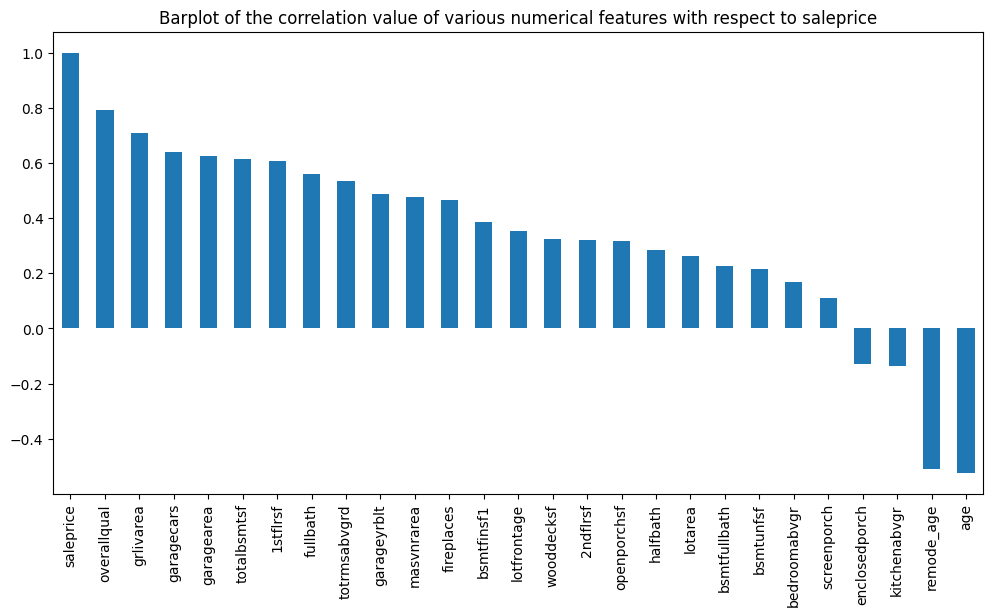

In [26]:
corelation = df[numerical_features].corr()['saleprice'].sort_values(ascending = False)  #finding the corelation value of all the numerical features with respect to the target variable saleprice
imp_num_features = corelation[abs(corelation) > 0.1]
plt.figure(figsize = (12,6))
imp_num_features.plot(kind='bar')
plt.title('Barplot of the correlation value of various numerical features with respect to saleprice')
plt.show()


In [28]:
imp_num_features = imp_num_features.index.tolist()  #extracting the feature names
imp_num_features

['saleprice',
 'overallqual',
 'grlivarea',
 'garagecars',
 'garagearea',
 'totalbsmtsf',
 '1stflrsf',
 'fullbath',
 'totrmsabvgrd',
 'garageyrblt',
 'masvnrarea',
 'fireplaces',
 'bsmtfinsf1',
 'lotfrontage',
 'wooddecksf',
 '2ndflrsf',
 'openporchsf',
 'halfbath',
 'lotarea',
 'bsmtfullbath',
 'bsmtunfsf',
 'bedroomabvgr',
 'screenporch',
 'enclosedporch',
 'kitchenabvgr',
 'remode_age',
 'age']

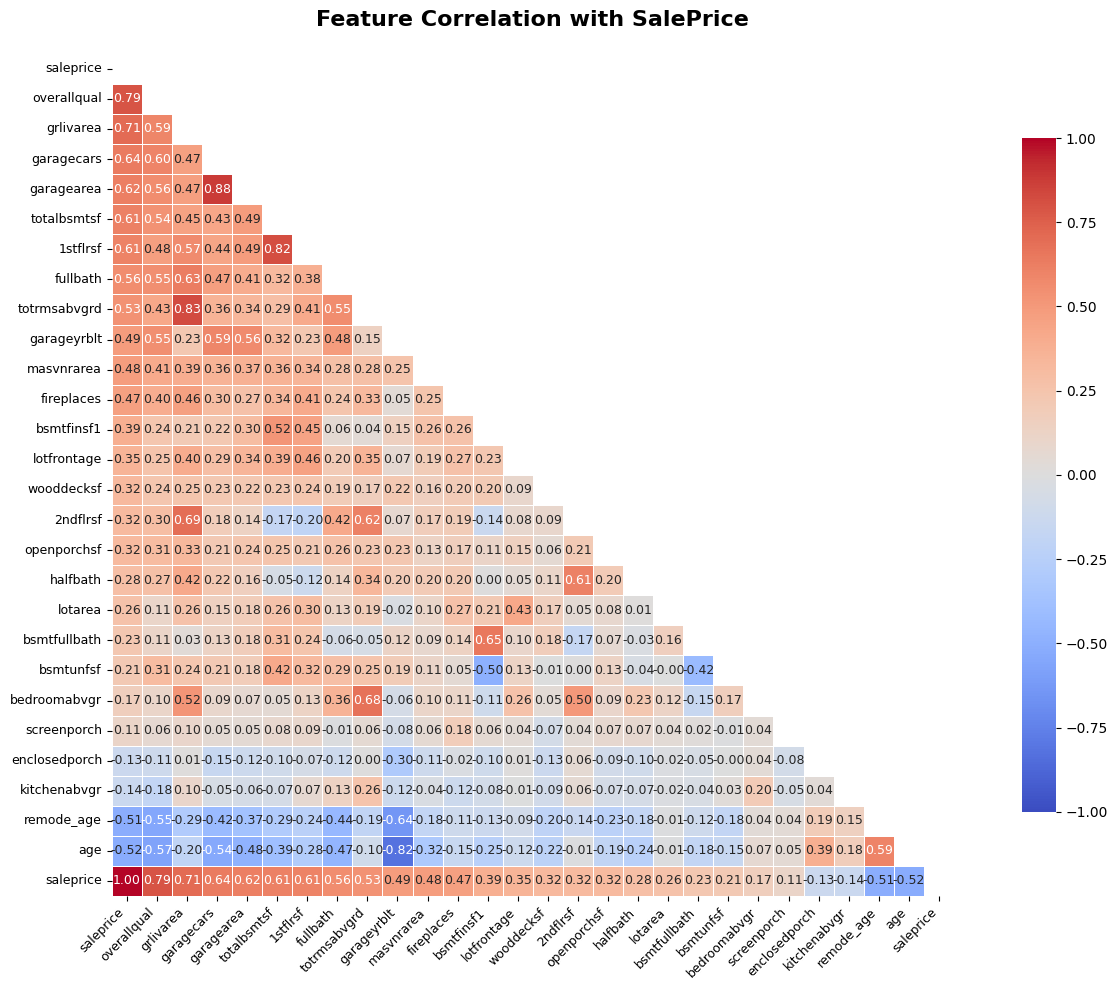

In [29]:
plt.figure(figsize=(14, 10))
corr_matrix = df[imp_num_features + ['saleprice']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,                    # hide upper triangle
    annot=True,                   # show values
    fmt='.2f',                    # 2 decimal places
    cmap='coolwarm',              # color scheme
    center=0,                     # center color at 0
    vmin=-1, vmax=1,              # fix color scale
    linewidths=0.5,               # add grid lines between cells
    linecolor='white',            # grid line color
    annot_kws={'size': 9},        # annotation font size
    square=True,                  # make cells square
    cbar_kws={'shrink': 0.8}      # resize the color bar
)

plt.title('Feature Correlation with SalePrice', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

**From the plot above we can observe that, grlivarea and totrmsabvgrd have a high corelation of 0.83, garage area and garagecars have high corelation of 0.88, 1stflrsf and totalbsmtsf have that of 0.82**


**And as we can observe from the plot above that totrmsabvgrd has lower correlation value compared to grlivarea, so we are dropping totrmsabvgrd** **Dropping garage area between garage cars and garage area, also dropping totalbsmtsf which is a total sqrft of basement area between this and 1st floor sqrtft**